In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('../data/raw/creditcard.csv')
print(df.info())
print(df.describe())
print(f"Missing values:\n{df.isnull().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
print(f"\nClass Distribution:")
print(df['Class'].value_counts())
print(f"Fraud Rate: {df['Class'].mean()*100:.3f}%")


Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Fraud Rate: 0.173%


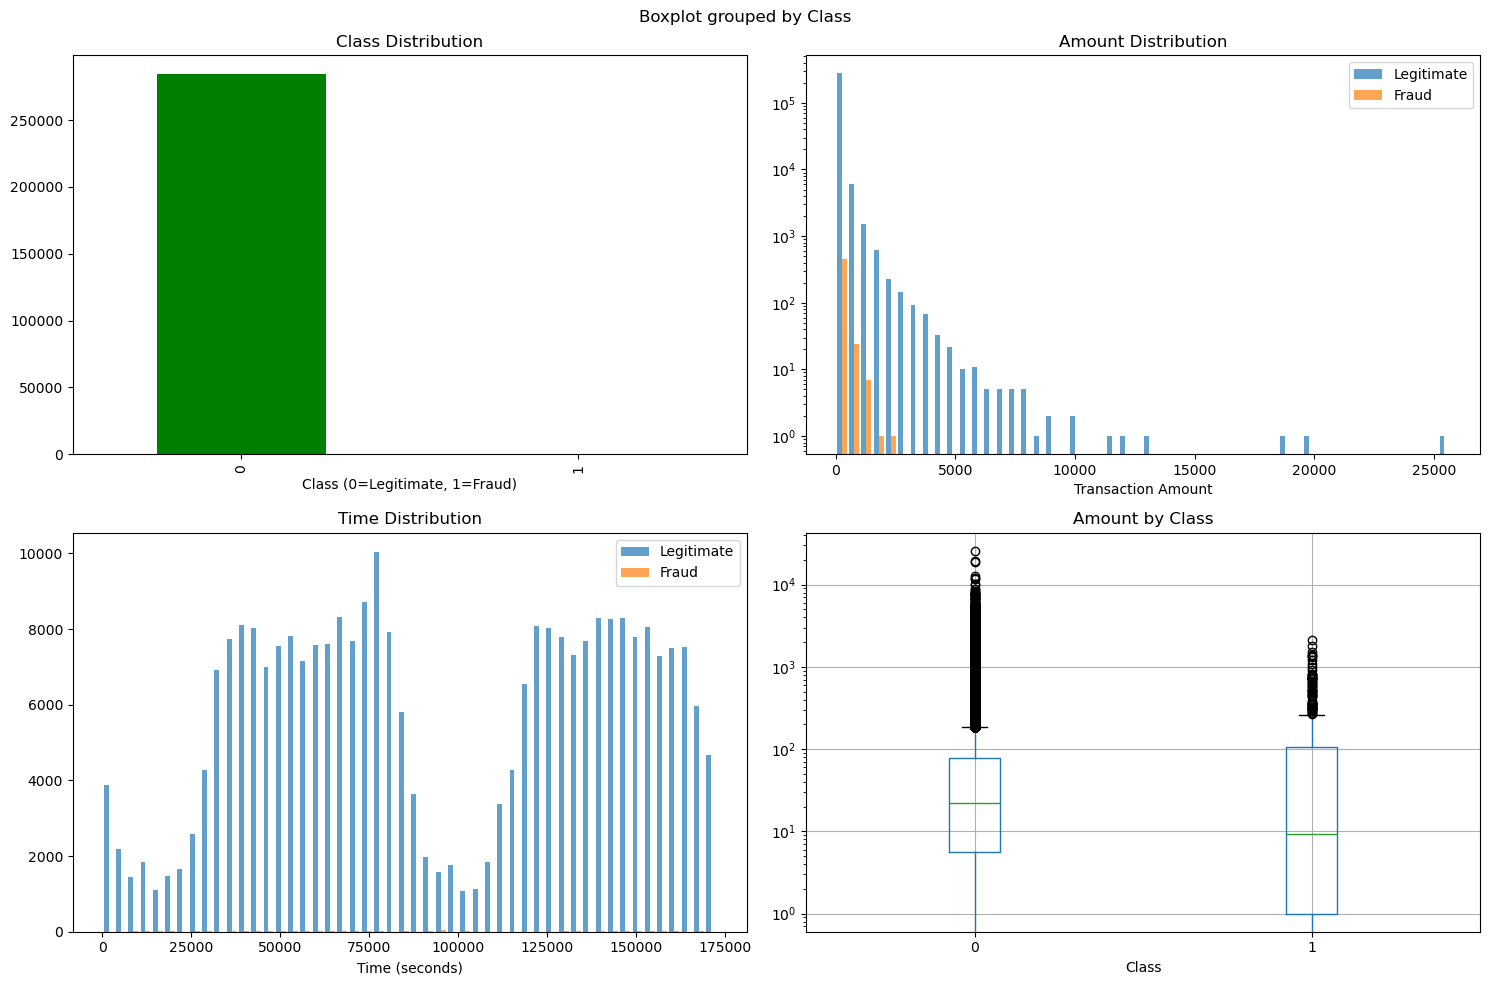

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10)) 

# 1 class distribution
df['Class'].value_counts().plot(kind='bar', ax=axes[0,0], color=['green', 'red'])
axes[0,0].set_title('Class Distribution')
axes[0,0].set_xlabel('Class (0=Legitimate, 1=Fraud)')

# 2 amount distribution by class
axes[0,1].hist([df[df['Class']==0]['Amount'], df[df['Class']==1]['Amount']], 
               bins=50, label=['Legitimate', 'Fraud'], alpha=0.7)
axes[0,1].set_xlabel('Transaction Amount')
axes[0,1].set_yscale('log')
axes[0,1].legend()
axes[0,1].set_title('Amount Distribution')
# 3 time distribution
axes[1,0].hist([df[df['Class']==0]['Time'], df[df['Class']==1]['Time']], 
               bins=50, label=['Legitimate', 'Fraud'], alpha=0.7)
axes[1,0].set_xlabel('Time (seconds)')
axes[1,0].legend()
axes[1,0].set_title('Time Distribution')

# 4 amount boxplot
df.boxplot(column='Amount', by='Class', ax=axes[1,1])
axes[1,1].set_yscale('log')
axes[1,1].set_title('Amount by Class')

plt.tight_layout()
plt.savefig('../docs/images/eda_overview.png')
plt.show()


Top 10 features correlated with fraud:
Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64


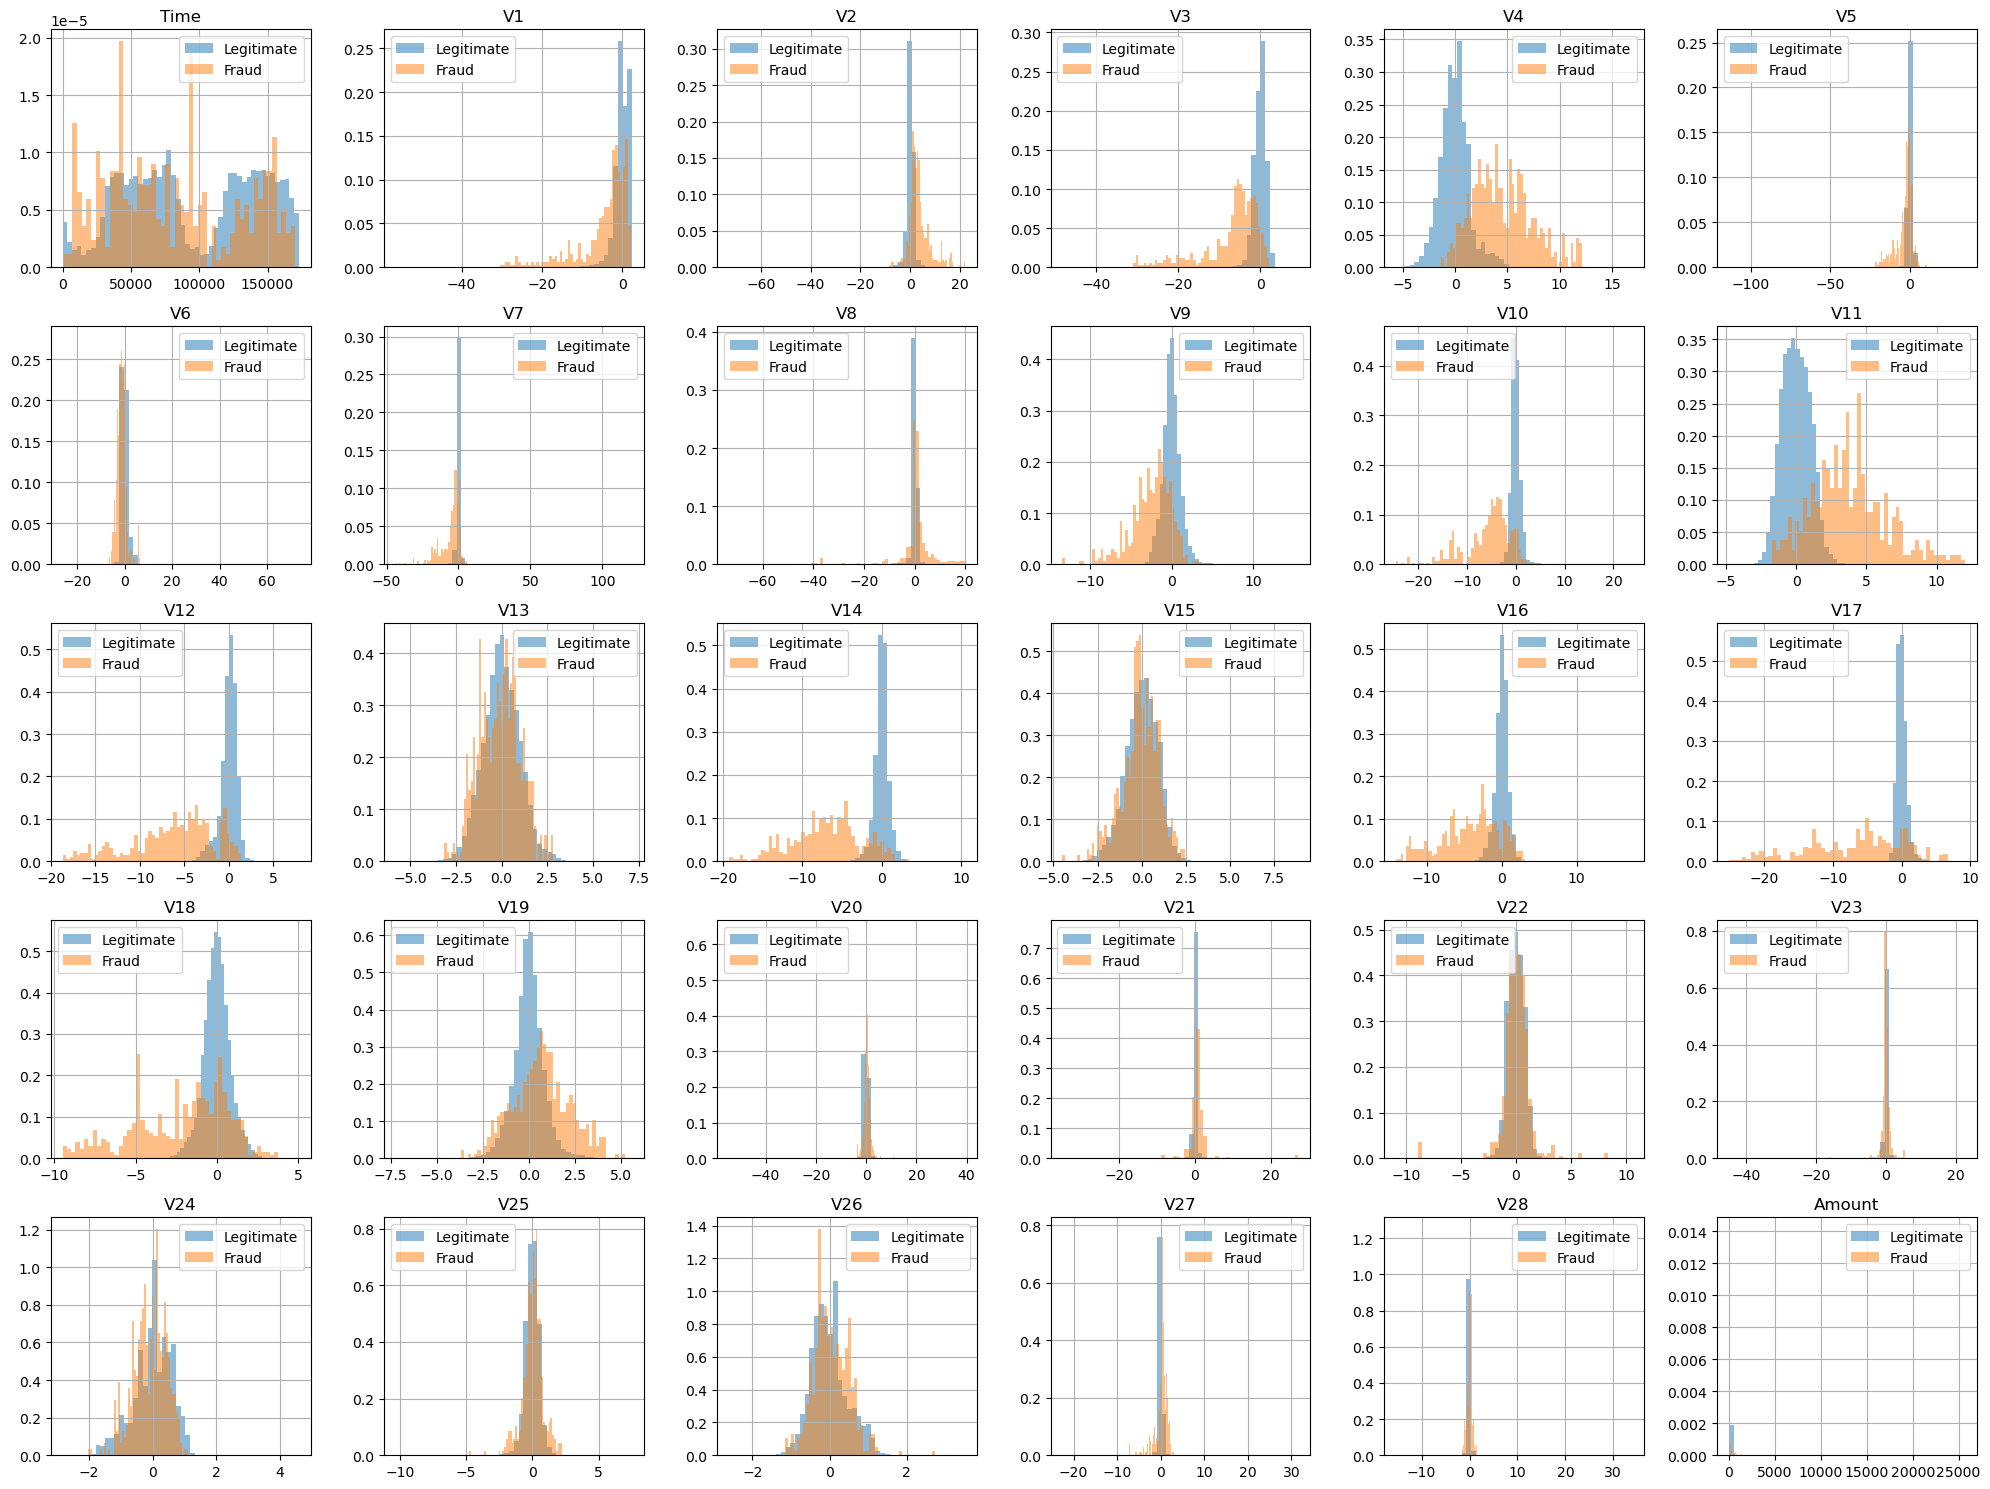

In [ ]:
# Correlation with fraud
correlations = df.corr()['Class'].sort_values(ascending=False)
print("\nTop 10 features correlated with fraud:")
print(correlations.head(10))

# distributions for fraud vs legitimate
fig, axes = plt.subplots(5, 6, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(df.columns[:-1]):  
    if i < 30:
        df[df['Class']==0][col].hist(bins=50, alpha=0.5, label='Legitimate', ax=axes[i], density=True)
        df[df['Class']==1][col].hist(bins=50, alpha=0.5, label='Fraud', ax=axes[i], density=True)
        axes[i].set_title(col)
        axes[i].legend()

plt.tight_layout()
plt.savefig('../docs/images/feature_distributions.png')
plt.show()